In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import math
from iminuit import Minuit
from iminuit.cost import LeastSquares
from fit import fit, calc_mean_dev

In [33]:
# formula trigonometrica per trovare theta 
def calc_theta (r, d) :
    return math.atan(r/d)

# formula errore di theta
def calc_theta_err (r, d, r_err, d_err) :
    A = 1/(r**2 + d**2)
    return A*((r*d_err)**2 + (d*r_err)**2)**0.5

# formula fit lineare
def retta (x, A, B) :
    return A * x + B

#fomula errore su d 

# formula per il t-test
def t_test (valore_teorico, valore_sperimentale, sigma_sperimentale, N) :
    if (valore_teorico - valore_sperimentale) < 0 :
        return (valore_sperimentale - valore_teorico) / (sigma_sperimentale/math.sqrt(N))
    else :
        return (valore_teorico - valore_sperimentale) / (sigma_sperimentale/math.sqrt(N))

# formula per cacolare d muovendo gli specchi
def calc_d_mov_specchi (laser, theta, delta_N) :
    return (delta_N * laser)/(2*theta)

# formula errore delta d
def delta_d_err (laser, theta, delta_N, theta_err, N_err) :
    C = laser/2*np.cos(theta)
    return C * (N_err**2 + (delta_N*np.tan(theta)**2)*theta_err**2)**0.5

# formula per calcolare m 
def calc_m (laser, d_spessore, delta_P, delta_N) :
    return (delta_N * laser)/(2*d_spessore*delta_P) 

INTERFEROMETRO FABRY-PEROT

In [3]:
# misure distanza puntatore-schermo
d_schermo = [161.4, 161.3, 161.4, 161.5, 161.4]
d_schermo_mean, d_schermo_dev = calc_mean_dev(d_schermo)
print(f"Distanza schermo: {d_schermo_mean:.2f} ± {d_schermo_dev:.2f} cm") 

Distanza schermo: 161.40 ± 0.06 cm


In [4]:
# misure diametri frange
N = [5, 4, 3, 2, 1]         # numero di interferenza costruttiva delle frange, mancano le frange N=5, che sono quelle più piccole e difficili da misurare
d_5 = [2.68, 2.77, 2.96, 2.82, 2.93]
d_4 = [5.01, 4.98, 4.99, 5.03, 5.06]
d_3 = [6.38, 6.41, 6.36, 6.41, 6.38]
d_2 = [7.49, 7.58, 7.51, 7.59, 7.51]
d_1 = [8.65, 8.57, 8.61, 8.6, 8.57]
 
d_5_mean, d_5_dev = calc_mean_dev(d_5)
d_4_mean, d_4_dev = calc_mean_dev(d_4)  
d_3_mean, d_3_dev = calc_mean_dev(d_3)
d_2_mean, d_2_dev = calc_mean_dev(d_2)
d_1_mean, d_1_dev = calc_mean_dev(d_1)
print(f"Diametro frange N=5: {d_5_mean:.2f} ± {d_5_dev:.2f} cm")
print(f"Diametro frange N=4: {d_4_mean:.2f} ± {d_4_dev:.2f} cm")
print(f"Diametro frange N=3: {d_3_mean:.2f} ± {d_3_dev:.2f} cm")
print(f"Diametro frange N=2: {d_2_mean:.2f} ± {d_2_dev:.2f} cm")
print(f"Diametro frange N=1: {d_1_mean:.2f} ± {d_1_dev:.2f} cm")


Diametro frange N=5: 2.83 ± 0.10 cm
Diametro frange N=4: 5.01 ± 0.03 cm
Diametro frange N=3: 6.39 ± 0.02 cm
Diametro frange N=2: 7.54 ± 0.04 cm
Diametro frange N=1: 8.60 ± 0.03 cm


In [5]:
# misura distanza tra gli specchi
d_specchi = [0.62, 0.63, 0.64, 0.64]
d_specchi_mean, d_specchi_dev = calc_mean_dev(d_specchi)
print(f"Distanza specchi: {d_specchi_mean:.2f} ± {d_specchi_dev:.2f} cm")

Distanza specchi: 0.63 ± 0.01 cm


In [44]:
# troviamo theta per ciascuna frangia
theta = [0] * 5
theta[0]= calc_theta(d_5_mean/2, d_schermo_mean)
theta[1] = calc_theta(d_4_mean/2, d_schermo_mean)
theta[2] = calc_theta(d_3_mean/2, d_schermo_mean)
theta[3] = calc_theta(d_2_mean/2, d_schermo_mean)
theta[4] = calc_theta(d_1_mean/2, d_schermo_mean)

theta_err = [0] * 5
theta_err[0] = calc_theta_err(d_5_mean/2, d_schermo_mean, d_5_dev/2, d_schermo_dev)
theta_err[1] = calc_theta_err(d_4_mean/2, d_schermo_mean, d_4_dev/2, d_schermo_dev)
theta_err[2] = calc_theta_err(d_3_mean/2, d_schermo_mean, d_3_dev/2, d_schermo_dev)
theta_err[3] = calc_theta_err(d_2_mean/2, d_schermo_mean, d_2_dev/2, d_schermo_dev)
theta_err[4] = calc_theta_err(d_1_mean/2, d_schermo_mean, d_1_dev/2, d_schermo_dev)

for i in range(5) :
    print(f"Theta frange N = {N[i]}: {theta[i]:.5f} ± {theta_err[i]}")

print("\n")
new_theta_err = [0] * 5
for i in range(5) :
    new_theta_err[i] = np.sin(theta_err[i])
    print(f"Errore sul coseno di theta frange N = {N[i]}: {new_theta_err[i]:.7f}")

Theta frange N = 5: 0.00877 ± 0.000319182220326807
Theta frange N = 4: 0.01553 ± 8.911282964827366e-05
Theta frange N = 3: 0.01979 ± 6.054512819452426e-05
Theta frange N = 2: 0.02334 ± 0.00012663142973555737
Theta frange N = 1: 0.02664 ± 9.242385463753104e-05


Errore sul coseno di theta frange N = 5: 0.0003192
Errore sul coseno di theta frange N = 4: 0.0000891
Errore sul coseno di theta frange N = 3: 0.0000605
Errore sul coseno di theta frange N = 2: 0.0001266
Errore sul coseno di theta frange N = 1: 0.0000924


In [45]:
# eseguiamo il fit lineare
for i in range(5) :
    theta[i] = np.cos(theta[i])
m_fit, q_fit, m_err, q_err, cov_AB = fit(N, theta, new_theta_err, retta)

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 0.00153 (χ²/ndof = 0.0)    │              Nfcn = 50               │
│ EDM = 1.15e-17 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ A    │  0.08e-3  │  0.04e-3  │            │            │         │         │       │
│ 1 │ B    │ 999.57e-3 │  0.12e-3  │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───┬───────────────────┐
│   │        A        B │
├───┼───────────────────┤
│ A │ 1.52e-09  -4.2e-9 │
│ B │  -4.2e-9 1.32e-08 │
└───┴───────────────────┘

success of the fit:  True


Valore del fit ki-quadro:  0.0015304515174280383


Valore del numero di gradi di libertà:  3.0


Valore del fit ki-quadro ridotto:  0.0005101505058093461


associated p-value:  0.9999840834557879


Valori dei parametri di fit con le rispettive incertezze: 
A = 0.00008 +/- 0.00004
B = 0.99957 +/- 0.00011


┌───┬───────────────────┐
│   │        A        B │
├───┼───────────────────┤
│ A │ 1.52e-09  -4.2e-9 │
│ B │  -4.2e-9 1.32e-08 │
└───┴───────────────────┘


covarianza tra A e B:  -4.175035420964694e-09


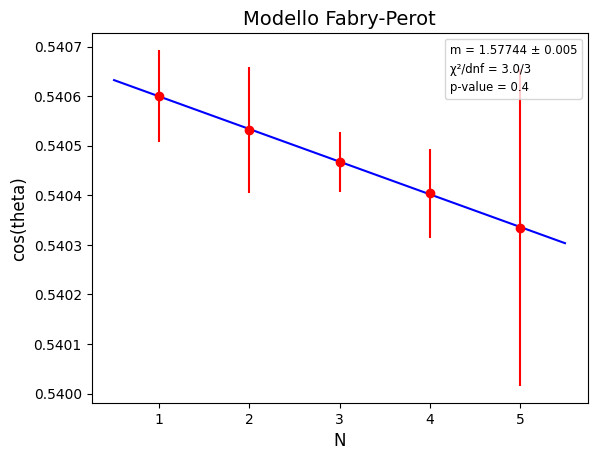

In [40]:
# plottiamo il grafico d'interpolazione lineare della retta
fig, ax = plt.subplots()
x_axis = np.linspace(0.5,5.5, 10000)
y_axis = np.arange(0., x_axis.size)

for i in range(x_axis.size):
    y_axis[i] = retta(x_axis[i], m_fit, q_fit)
plt.plot(x_axis, y_axis, color = 'b', label = 'Modello Fabry-Perot')

for i in range(len(N)):
    ax.errorbar(N[i], theta[i], xerr = 0, yerr = new_theta_err[i], color = 'r', linestyle = ':', marker = 'o')     

custom_lines = [Line2D([0], [0], color = 'None', marker = None, lw = 0),
                Line2D([0], [0], color = 'None', marker = None, lw = 0),
                Line2D([0], [0], color = 'None', marker = None, lw = 0)
            ]

labels = ['m = 1.57744 ± 0.005', 'χ²/dnf = 3.0/3', 'p-value = 0.4']

ax.set_title('Modello Fabry-Perot', size = 14)
ax.set_ylabel('cos(theta)', size = 12)
ax.set_xlabel('N', size = 12)

ax.legend( fontsize = "small", handles = custom_lines, labels = labels, handlelength=0, handletextpad=0, loc = 'upper right')
plt.show()

In [9]:
# troviamo d dai valori ricavati dal fit
lambda_He = 6.32e-5                                                #632.8 nm
d_specchi_spe = lambda_He / (2*m_fit)
d_specchi_spe_err = (lambda_He/2*m_fit**2) * m_err
print (f"Distanza specchi trovata: {d_specchi_spe:.4f} ± {d_specchi_spe_err} cm")

Distanza specchi trovata: -0.0047 ± 3.72852380906678e-11 cm


In [10]:
# calcoliamo il t-test per confrontare i due risultati
t_value = d_specchi_spe - d_specchi_mean / (d_specchi_spe_err**2 + d_specchi_dev**2)**0.5
print(f"t-test value: {t_value:.2f}")

t-test value: -76.29


In [19]:
# calcoliamo d dalla muovendo gli d_specchi (d circa di 20 micrometri)
delta_N = [56, 59, 60, 62, 59] 
delta_N_mean, delta_N_dev = calc_mean_dev(delta_N)
print(f"delta N : {delta_N_mean:.2f} ± {delta_N_dev:.2f}")

theta_1_frangia, theta_err_1_frangia =  0.00877, 0.1208966500776574

delta_d_spe = calc_d_mov_specchi (lambda_He, 1, delta_N_mean)
delta_d_spe_err = lambda_He/2 * delta_N_dev
print (f"Distanza tra gli specchi: {delta_d_spe:.5f} ± {delta_d_spe_err} cm")

delta N : 59.20 ± 1.94
Distanza tra gli specchi: 0.00187 ± 6.12746733977424e-05 cm


In [26]:
# calcoliamo il t-test per confrontare i due risultati
d_reale_specchi = 0.02          # sono 20 micrometri
t_value = np.abs((d_reale_specchi - delta_d_spe)/((0.01**2 + delta_d_spe_err**2)**0.5))
print(f"t-test value: {t_value:.2f}")

t-test value: 1.81


MICHELSON MORLEY

In [20]:
# calcoliamo d dalla muovendo gli d_specchi (d circa di 20 micrometri)
delta_N_mich = [63, 65, 67, 61, 64] 
delta_N_mean_mich, delta_N_dev_mich = calc_mean_dev(delta_N_mich)
print(f"delta N : {delta_N_mean_mich:.2f} ± {delta_N_dev_mich:.2f}")

delta_d_spe_mich = calc_d_mov_specchi (lambda_He, 1, delta_N_mean_mich)
delta_d_spe_err_mich = lambda_He/2 * delta_N_dev_mich
print (f"Distanza tra gli specchi: {delta_d_spe_mich:.5f} ± {delta_d_spe_err_mich} cm")

delta N : 64.00 ± 2.00
Distanza tra gli specchi: 0.00202 ± 6.32e-05 cm


In [24]:
# calcoliamo il t-test per confrontare i due risultati
d_reale_specchi = 0.02          # sono 20 micrometri
t_value = np.abs((d_reale_specchi - delta_d_spe_mich)/((0.01**2 + delta_d_spe_err_mich**2)**0.5))
print(f"t-test value: {t_value:.2f}")

t-test value: 1.80


In [21]:
# t-test per le misure fabry-perot e michelson 
t_test_finale = np.abs((delta_d_spe - delta_d_spe_mich)/((delta_d_spe_err**2 + delta_d_spe_err_mich**2)**0.5))
print(f"t-test finale: {t_test_finale:.2f}")

t-test finale: 1.72
